# CNN 모델 비교 학습 템플릿

`dataset/train`, `dataset/val`, `dataset/test` 폴더를 사용해서 여러 모델을 비교하는 노트북입니다.

실험 흐름은 설정 -> 학습 함수 -> 후보 모델 반복 실험 -> 최종 test 평가 순서로 정리되어 있습니다.


In [1]:
from pathlib import Path
import copy
import random
import time

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


c:\Projects\_active\focus_on_class\worktrees\3_compare\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 고정 설정

모델 비교 실험에서는 공통 하이퍼파라미터를 고정하고, 비교할 모델만 `candidate_models` 리스트로 관리합니다.


In [2]:
data_path = Path("dataset")
save_path = Path("models")
save_path.mkdir(parents=True, exist_ok=True)

image_size = 224
batch_size = 16
epochs = 20
learning_rate = 1e-4
weight_decay = 1e-4
seed = 42
freeze_backbone = True
run_final_test = False

candidate_models = [
    "resnet18",
    "resnet34",
    "mobilenet_v3_large",
    "efficientnet_b0",
    "efficientnet_v2_s",
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [3]:
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 2. 데이터 불러오기


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [5]:
train_data = datasets.ImageFolder(data_path / "train", transform=train_transform)
val_data = datasets.ImageFolder(data_path / "val", transform=test_transform)
test_data = datasets.ImageFolder(data_path / "test", transform=test_transform)

class_names = train_data.classes
class_count = len(class_names)

print(class_names)
print("train:", len(train_data), "val:", len(val_data), "test:", len(test_data))

['Attentive', 'Drowsy', 'LookingAway']
train: 1345 val: 171 test: 167


In [6]:
# train_loader는 각 모델 실험마다 새로 만들어서 같은 shuffle 순서로 시작합니다.
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


## 3. 모델 만들기

`model_list` 구조는 유지하고, `create_model(model_name, class_count)` 함수로 모델 생성, backbone freeze, 마지막 분류층 교체를 재사용합니다.


In [ ]:
def change_fc(model, class_count):
    model.fc = nn.Linear(model.fc.in_features, class_count)
    return model


def change_classifier(model, class_count):
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, class_count)
    return model


def freeze_model_backbone(model):
    for param in model.parameters():
        param.requires_grad = False
    return model


model_list = {
    "resnet18": [models.resnet18, models.ResNet18_Weights.IMAGENET1K_V1, change_fc],
    "resnet34": [models.resnet34, models.ResNet34_Weights.IMAGENET1K_V1, change_fc],
    "resnet50": [models.resnet50, models.ResNet50_Weights.IMAGENET1K_V1, change_fc],
    "mobilenet_v3_large": [models.mobilenet_v3_large, models.MobileNet_V3_Large_Weights.IMAGENET1K_V2, change_classifier],
    "efficientnet_b0": [models.efficientnet_b0, models.EfficientNet_B0_Weights.IMAGENET1K_V1, change_classifier],
    "efficientnet_b2": [models.efficientnet_b2, models.EfficientNet_B2_Weights.IMAGENET1K_V1, change_classifier],
    "efficientnet_b3": [models.efficientnet_b3, models.EfficientNet_B3_Weights.IMAGENET1K_V1, change_classifier],
    "efficientnet_v2_s": [models.efficientnet_v2_s, models.EfficientNet_V2_S_Weights.IMAGENET1K_V1, change_classifier],
}


def create_model(model_name, class_count):
    model_func, weights, change_last_layer = model_list[model_name]
    model = model_func(weights=weights)
    if freeze_backbone:
        model = freeze_model_backbone(model)
    model = change_last_layer(model, class_count)
    return model.to(device)


## 4. 학습 함수

여러 모델을 반복 학습할 수 있도록 학습/평가 함수는 필요한 객체를 모두 인자로 받습니다.


In [8]:
def train_one_epoch(model, optimizer, loss_fn, train_loader, train_data, device):
    model.train()

    total_loss = 0
    y_true = []
    y_pred = []

    for x, y in tqdm(train_loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        pred = model(x)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        y_true += y.cpu().tolist()
        y_pred += pred.argmax(1).cpu().tolist()

    train_loss = total_loss / len(train_data)
    train_acc = accuracy_score(y_true, y_pred)
    train_f1 = f1_score(y_true, y_pred, average="macro")

    return train_loss, train_acc, train_f1


def evaluate(model, loss_fn, loader, data, device):
    model.eval()

    total_loss = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in tqdm(loader, leave=False):
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = loss_fn(pred, y)

            total_loss += loss.item() * x.size(0)
            y_true += y.cpu().tolist()
            y_pred += pred.argmax(1).cpu().tolist()

    eval_loss = total_loss / len(data)
    eval_acc = accuracy_score(y_true, y_pred)
    eval_f1 = f1_score(y_true, y_pred, average="macro")

    return eval_loss, eval_acc, eval_f1, y_true, y_pred


In [9]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def measure_inference_time(model, loader, device, repeat_batches=10):
    model.eval()
    times = []

    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= repeat_batches:
                break

            x = x.to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start = time.perf_counter()
            _ = model(x)

            if device.type == "cuda":
                torch.cuda.synchronize()

            end = time.perf_counter()

            ms_per_image = (end - start) / x.size(0) * 1000
            times.append(ms_per_image)

    return float(np.mean(times))


## 5. 실험 실행 함수

모델 1개를 학습하고 validation 기준 최고 성능 checkpoint와 history를 저장하는 함수입니다.


In [10]:
def run_experiment(model_name):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    train_shuffle_seed = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
        generator=train_shuffle_seed,
    )

    model = create_model(model_name, class_count)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = []
    best_score = float('-inf')
    best_epoch = 0
    best_model = copy.deepcopy(model.state_dict())
    param_count = count_parameters(model)

    train_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model=model,
            optimizer=optimizer,
            loss_fn=loss_fn,
            train_loader=train_loader,
            train_data=train_data,
            device=device,
        )
        val_loss, val_acc, val_f1, _, _ = evaluate(
            model=model,
            loss_fn=loss_fn,
            loader=val_loader,
            data=val_data,
            device=device,
        )

        row = {
            "model_name": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
        }
        history.append(row)

        print(
            f"[{model_name}] {epoch:02d}/{epochs} | "
            f"train acc {train_acc:.4f} f1 {train_f1:.4f} | "
            f"val acc {val_acc:.4f} f1 {val_f1:.4f}"
        )

        if val_f1 > best_score:
            best_score = val_f1
            best_epoch = epoch
            best_model = copy.deepcopy(model.state_dict())

    train_time_sec = time.perf_counter() - train_start

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[history_df["val_f1"].idxmax()].to_dict()

    model.load_state_dict(best_model)
    val_inference_ms_per_image = measure_inference_time(model, val_loader, device)

    checkpoint_path = save_path / f"{model_name}_best.pt"
    history_path = save_path / f"{model_name}_history.csv"

    torch.save(
        {
            "model_state": model.state_dict(),
            "class_names": class_names,
            "image_size": image_size,
            "model_name": model_name,
            "best_val": best_row,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "epochs": epochs,
            "seed": seed,
            "freeze_backbone": freeze_backbone,
            "param_count": param_count,
            "val_inference_ms_per_image": val_inference_ms_per_image,
        },
        checkpoint_path,
    )
    history_df.to_csv(history_path, index=False, encoding="utf-8-sig")

    result = {
        "model_name": model_name,
        "best_epoch": best_epoch,
        "best_val_loss": best_row["val_loss"],
        "best_val_acc": best_row["val_acc"],
        "best_val_f1": best_row["val_f1"],
        "param_count": param_count,
        "train_time_sec": train_time_sec,
        "val_inference_ms_per_image": val_inference_ms_per_image,
        "checkpoint_path": str(checkpoint_path),
        "history_path": str(history_path),
    }

    return result, history_df


## 6. 후보 모델 반복 실험

`candidate_models`에 들어 있는 모델을 순서대로 학습하고, validation macro F1 기준으로 비교합니다.


In [11]:
all_results = []
all_histories = []

for name in candidate_models:
    result, history_df = run_experiment(name)
    all_results.append(result)
    all_histories.append(history_df)

summary_df = pd.DataFrame(all_results)
summary_df = summary_df.sort_values("best_val_f1", ascending=False).reset_index(drop=True)

summary_df


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:05<00:00, 8.21MB/s]


[resnet18] 01/20 | train acc 0.3368 f1 0.3272 | val acc 0.4094 f1 0.2925


[resnet18] 02/20 | train acc 0.4468 f1 0.4398 | val acc 0.5731 f1 0.5091


[resnet18] 03/20 | train acc 0.5472 f1 0.5386 | val acc 0.6257 f1 0.5638


...

[efficientnet_v2_s] 17/20 | train acc 0.7599 f1 0.7549 | val acc 0.8363 f1 0.8288


[efficientnet_v2_s] 18/20 | train acc 0.7740 f1 0.7701 | val acc 0.8421 f1 0.8327


[efficientnet_v2_s] 19/20 | train acc 0.7494 f1 0.7443 | val acc 0.8363 f1 0.8309


[efficientnet_v2_s] 20/20 | train acc 0.7599 f1 0.7567 | val acc 0.8421 f1 0.8365


,model_name,best_epoch,best_val_loss,best_val_acc,best_val_f1,param_count,train_time_sec,val_inference_ms_per_image,checkpoint_path,history_path
0,mobilenet_v3_large,20,0.497483,0.853801,0.852181,4205875,91.773154,0.691169,models\mobilenet_v3_large_best.pt,models\mobilenet_v3_large_history.csv
1,resnet18,19,0.517412,0.847953,0.844078,11178051,84.720747,0.708982,models\resnet18_best.pt,models\resnet18_history.csv
2,efficientnet_v2_s,16,0.619698,0.847953,0.843513,20181331,106.577073,1.469240,models\efficientnet_v2_s_best.pt,models\efficientnet_v2_s_history.csv
3,resnet34,19,0.548273,0.824561,0.822446,21286211,95.584643,0.876014,models\resnet34_best.pt,models\resnet34_history.csv
4,efficientnet_b0,19,0.565138,0.818713,0.818304,4011391,88.905426,0.759806,models\efficientnet_b0_best.pt,models\efficientnet_b0_history.csv


## 7. 비교 결과 저장

모델별 summary와 전체 epoch history를 CSV로 저장합니다.


In [12]:
summary_path = save_path / "model_compare_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

summary_path


WindowsPath('models/model_compare_summary.csv')

In [13]:
all_history_df = pd.concat(all_histories, ignore_index=True)

all_history_path = save_path / "model_compare_all_history.csv"
all_history_df.to_csv(all_history_path, index=False, encoding="utf-8-sig")

all_history_path


WindowsPath('models/model_compare_all_history.csv')

## 8. 최종 모델 1개 test 평가

모델 비교가 끝난 뒤 validation macro F1이 가장 높은 모델 1개만 test set으로 최종 평가합니다.


In [14]:
best_model_name = summary_df.iloc[0]["model_name"]
best_checkpoint_path = summary_df.iloc[0]["checkpoint_path"]

print("Best model:", best_model_name)
print("Checkpoint:", best_checkpoint_path)


Best model: mobilenet_v3_large
Checkpoint: models\mobilenet_v3_large_best.pt


In [15]:
checkpoint = torch.load(best_checkpoint_path, map_location=device)

final_model = create_model(
    model_name=checkpoint["model_name"],
    class_count=len(checkpoint["class_names"]),
)

final_model.load_state_dict(checkpoint["model_state"])
final_model.to(device)

test_loss, test_acc, test_f1, y_true, y_pred = evaluate(
    model=final_model,
    loss_fn=nn.CrossEntropyLoss(),
    loader=test_loader,
    data=test_data,
    device=device,
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")
print(f"Test F1  : {test_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=class_names))


Test Loss: 0.4805
Test Acc : 0.8922
Test F1  : 0.8915

              precision    recall  f1-score   support

   Attentive       0.87      0.91      0.89        53
      Drowsy       0.90      0.93      0.92        58
 LookingAway       0.90      0.84      0.87        56

    accuracy                           0.89       167
   macro avg       0.89      0.89      0.89       167
weighted avg       0.89      0.89      0.89       167



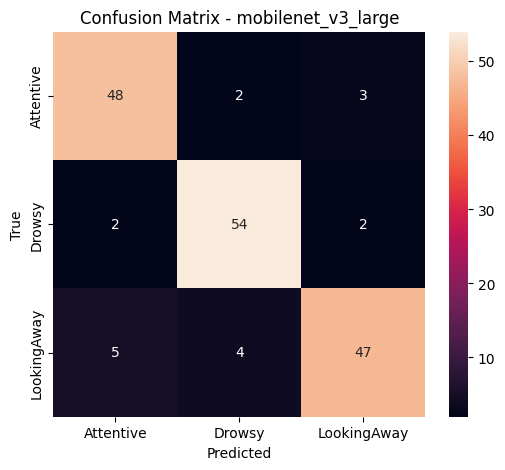

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


## 9. 단일 모델 디버그용

기존처럼 모델 하나를 수동으로 확인하고 싶다면 아래 주석 셀을 복사해서 임시로 사용하면 됩니다. 기본 비교 흐름에서는 실행하지 않습니다.


In [17]:
# debug_model_name = "resnet18"
# debug_result, debug_history_df = run_experiment(debug_model_name)
# debug_history_df


## 비교를 위해 고정하면 좋은 것

- 데이터셋 폴더와 train/val/test 분할
- 클래스 이름과 클래스 순서
- 이미지 크기와 Normalize 값
- train 증강 방식
- batch size, epoch, optimizer, learning rate, weight decay
- random seed
- pretrained 사용 여부
- backbone freeze 여부
- best model 선택 기준: 현재는 `val_f1`
- 평가 지표: Accuracy, Macro F1, 추론 시간
